In [5]:
# Cell 1 — Load
import pandas as pd, sys; sys.path.append("..")
from src.funnel_analyzer import build_funnel, device_funnel, hourly_drop_pattern
from src.visualizer import plot_funnel_bars, plot_dropoff_reasons, plot_device_conversion, plot_plotly_funnel

df = pd.read_csv("../data/raw/sessions.csv")


,stage,users,drop_off,drop_off_pct,stage_conv_pct,overall_conv
0,landing,15000,0.0,0.00,0.00,100.00
1,browse,10413,4587.0,30.58,69.42,69.42
2,product_detail,7053,3360.0,32.27,67.73,47.02
3,add_to_cart,3934,3119.0,44.22,55.78,26.23
4,checkout,2101,1833.0,46.59,53.41,14.01
5,payment,1269,832.0,39.60,60.40,8.46
6,order_confirmed,744,525.0,41.37,58.63,4.96


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/figures/funnel_bars.png'

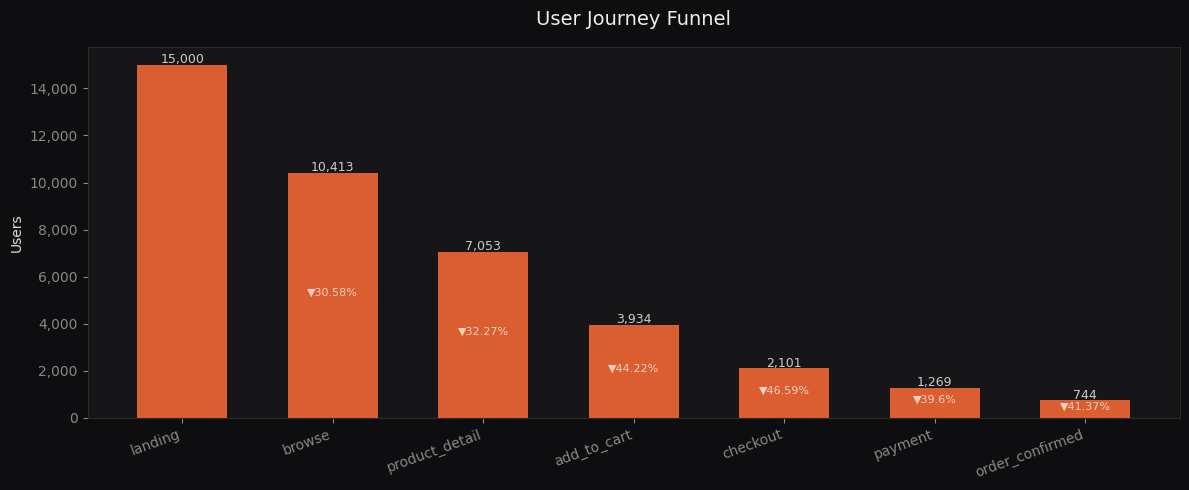

In [6]:
# Cell 2 — Funnel
funnel = build_funnel(df)
display(funnel)
plot_funnel_bars(funnel, save_path="../outputs/figures/funnel_bars.png")
plot_plotly_funnel(funnel)

,conversions,sessions,conv_rate
device,,,
desktop,307,4861,6.32
mobile,330,8675,3.80
tablet,107,1464,7.31


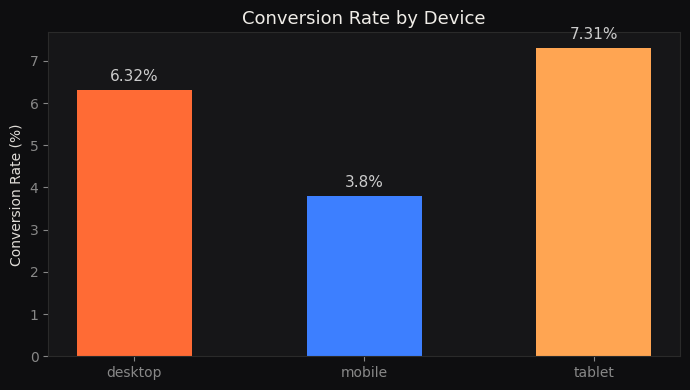

In [7]:
# Cell 3 — Device breakdown
device_df = device_funnel(df)
display(device_df)
plot_device_conversion(device_df)

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/figures/exit_add_to_cart.png'

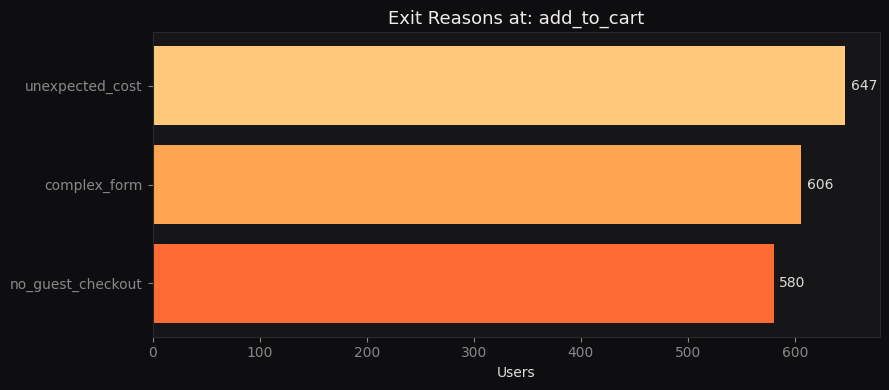

In [8]:
# Cell 4 — Exit reasons per stage
for stage in ["add_to_cart","checkout","payment"]:
    plot_dropoff_reasons(df, stage, save_path=f"../outputs/figures/exit_{stage}.png")

<Axes: title={'center': 'Drop-off Rate by Hour of Day'}, xlabel='hour'>

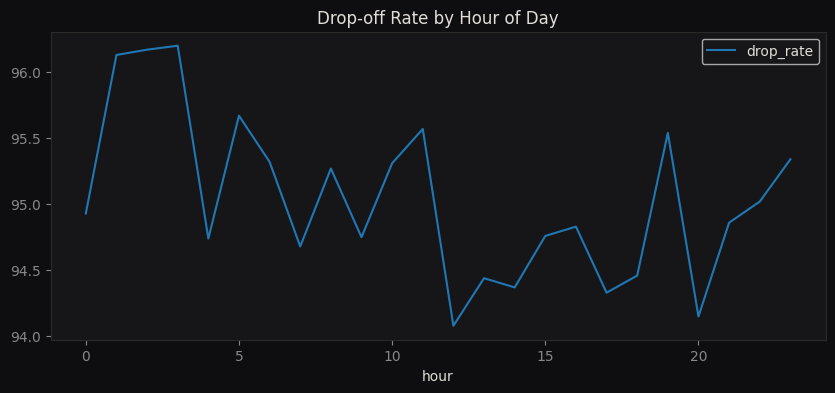

In [9]:
# Cell 5 — Hourly pattern
hourly = hourly_drop_pattern(df)
hourly.plot(y="drop_rate", title="Drop-off Rate by Hour of Day", figsize=(10,4))

In [10]:
# Cell 6 — Save processed funnel
funnel.to_csv("../data/processed/funnel_summary.csv", index=False)